# Notebook 0 - Setup

This notebook is a basic notebook in order to check your initial level and to present to you how the course will be done.

## Python Basis

I assume you guys have already a bit of experience in Python, but you know, it is really easier to check for ourselves instead of assuming it.\
So, let's start with a warmup exercise.\
I will give you some snippet of code and you will ne to fill in the remaining code (the `TODO` lines).

### Collatz Conjecture

I don't know who of you guys ever heard of this conjecture: it is an unproven conjecture that states something like this: 

Take any integer number $n \in \mathbb{N}$

* now, if the number is even, divide it by $2$, $n \to \frac{n}{2}$
* otherwise, multiply by $3$ and add $1$, $n \to 3n + 1$
* repeat

eventually, no matter the starting number, you will end up with the infinite loop sequence $4, 2, 1, 4, 2, 1, ...$.

Now, I really think you can start by implementing a simple function, what do you think?

In [20]:
def collatz_step(n):
    
    # Implement the procedure described above
    # so if n is even, return half n
    # otherwise return 3n + 1
    # implement one step, not the whole procedure
    
    if (n % 2 == 0):
        return n // 2
    else:
        return 3 * n + 1
    
    
    
    ...

Once we have the single step function, let's do something *fancy* (not really, anyway).\
Let's compute how many steps it takes for a given number to arrive to the $4, 2, 1, ...$ loop.\
By definition $4, 2, 1$ are already in the loop so the number of steps for each of them is simply $0$.

In [21]:
def steps_to_loop(n, n_steps_to_loop):
    if n in (1, 2, 4):
        return 0

    if n in n_steps_to_loop:
        return n_steps_to_loop[n]

    next_n = collatz_step(n)
    steps = 1 + steps_to_loop(next_n, n_steps_to_loop)

    n_steps_to_loop[n] = steps
    return steps

Okay, do we have it? Good. Let's make things a bit harder. Let's try to collect for a given range of numbers the number of steps that each number in the range takes to loop.\
Let's use a dictionary to store the range of numbers, okay?

In [22]:
n_min = 1
n_max = 1000000

In [23]:
n_steps_to_loop = {}

for n in range(n_min, n_max + 1):
    n_steps_to_loop[n] = steps_to_loop(n,n_steps_to_loop)
    

# Implement the procedure described above
# TODO

Okay, what do you think the perfomance are?\
I mean, for this benchmark we can just look at the time the cell took to execute.\
But we can also try something a bit more *sophisticated*: let's use the `perf_counter()` function from the `time` module.

In [24]:
from time import perf_counter

In [25]:
t0 = perf_counter()

# insert here the procedure
n_steps_to_loop = {}

for n in range(n_min, n_max + 1):
    n_steps_to_loop[n] = steps_to_loop(n,n_steps_to_loop)
    

# Implement the procedure described above
# TODO
t1 = perf_counter()

# compute the resulting time for the procedure
# TODO
print(f"Time to compute steps to loop for {n_max} numbers: {t1 - t0:.2f} seconds")

# notice that it will be really similar to the cell execution time
# but it is nice to know how to use perf_counter in general
# when you want to measure performances (even if in real
# application you will use profilers)

Time to compute steps to loop for 1000000 numbers: 0.54 seconds


Okay, do you think that it is a good way of computing the procedure? Do you see any possible improvement?\
Let's try something a bit more difficult, by leveraging the fact that while computing the collatz series of a number, you will use a lot of already existing collatz series of other numbers.\
This is something that we can do pretty easily with dictionaries!

If you didn't understand, follow this example:

you know that $3$ has a `steps_to_loop` equal to $5$.\
Let's now consider the number $6$:\
6 is not in the $4, 2, 1, ...$ loop, so it will need at least 1 steps to loop.\
If you divide it by 2 (following the `collatz_step`) it will become a 3.\
Now you already know the value for 3!\
So do not recompute it all, just use what you already know to obtain that $6$ has `steps_to_loop` equal to $6$ (which is just $5+1$)!

In [26]:
n_steps_to_loop = {} # Maybe you wanna do something different this time?
# here we could use some recursion
# or also a procedural function
# it is really up to you!
# before writing the code, 
# take a piece of paper and try to visualize your idea,
# write it down, and try simple cases.
# ask for help if you want, and discuss with your friends!
# but DO NOT USE LLM
# LLM are good, of course. but at this point
# you should be focusing on learning how to solve this
# simple exercise, not in obtaining a solution!


t0 = perf_counter()
# Implement the procedure described above
# TODO
for n in range(n_min, n_max + 1):
    if(n in n_steps_to_loop):
        continue
    n_steps_to_loop[n] = steps_to_loop(n,n_steps_to_loop)
    
t1 = perf_counter()
# compute the time taken
# is it faster?
print(f"Time to compute steps to loop for {n_max} numbers: {t1 - t0:.2f} seconds")

Time to compute steps to loop for 1000000 numbers: 0.53 seconds


Let's also remove all the additional keys added to the dictionary that does not belong to the desired range.

In [ ]:
# TODO
for n in list(n_steps_to_loop):
    if n < n_min or n > n_max:
        del n_steps_to_loop[n]

Great! Seems like it worked, didn't it?\
A basic recursive implementation (you could also have used other techniques) should bring the computation time (in the range $[1, 10^6]$) from $\approx 9$ to $\approx 0.5$ seconds.\
**It is $\times 18$ improvement! Great!**

If it didn't, don't worry. I wanted to test your knowledge with dictionaries and with algorithms! Even if it could seem not really related you'll find usefull at some point this optimization technique used here, which is called **mnemonization**.

Of course you should know that Python is not the right programming language to do optimization, but anyway, is good to have a flavour about how optimization can cut really a lot of computation!

Now let's finish this simple warm up exercise with some visualization.\
Because a data scientist must always know how to let other people visualize his/her results!

In [28]:
from matplotlib import pyplot as plt

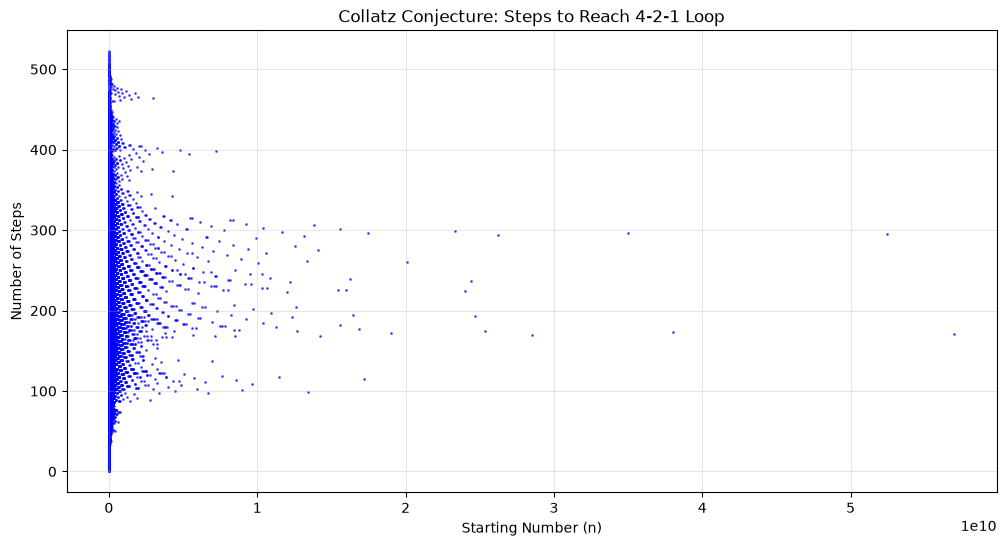

In [29]:
# Extract data from the previously populated dictionary
x = list(n_steps_to_loop.keys())
y = list(n_steps_to_loop.values())

# Create the scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(x, y, s=1, alpha=0.6, color='blue')
plt.title("Collatz Conjecture: Steps to Reach 4-2-1 Loop")
plt.xlabel("Starting Number (n)")
plt.ylabel("Number of Steps")
plt.grid(True, alpha=0.3)
plt.show()

## About the course

So, now we arrive at the part where we talks about tutoring, projects and exam.

As you already know there will be lectures, tutoring, some homeworks, some projects and a final exam (written + oral).\
As mentioned in the slide of the course, this is the final grade weights for each part:

| Grading Key | Weight |
|-|-|
| Written Exam | 70% |
| Oral Exam | 20% |
| Projects | 10% |
| Homeworks | 10% |

As you now you will do the homeworks in team while the projects individually.

The tutoring will usually be composed by **warmup exercise** and then application of what done in the lecture on the **vacuum world**.

The projects will be one about **Taxi Driver** and the other about **Forza 4**. Projects will be evaulated in comparison wrt other students, so implement the better solution you can think of in order to achieve the best possible score!